# <b><font color='teal'>Практикум</font></b>

### <font color='teal'>Предварительная очистка и обработка данных о сне и образе жизни</font>
Датасет: Sleep Health and Lifestyle Dataset содержит информацию о 374 респондентах с 13 признаками. <br>
<i>Описание данных:</i>
- Person ID: Уникальный идентификатор
- Gender: Пол (Male/Female)
- Age: Возраст
- Occupation: Профессия
- Sleep Duration: Продолжительность сна (часы)
- Quality of Sleep: Качество сна (оценка от 1 до 10)
- Physical Activity Level: Уровень физической активности (минуты в день)
- Stress Level: Уровень стресса (оценка от 1 до 10)
- BMI Category: Категория МТ (Normal, Overweight, Obese)
- Blood Pressure: Артериальное давление (систолическое/диастолическое)
- Heart Rate: Сердечный ритм (удары в минуту)
- Daily Steps: Количество шагов в день
- Sleep Disorder: Наличие расстройства сна (None, Insomnia, Sleep Apnea)

In [1]:
# импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
import scipy.stats


<b> 1. Загрузка и первичный анализ </b>

In [110]:
# Загрузите датасет Sleep_health_and_lifestyle_dataset.csv
df_sleep = pd.read_csv('../data/Sleep_health_and_lifestyle_dataset.csv')
pd.set_option("display.max_rows", 30)
pd.set_option("display.max_columns", 20)
display(df_sleep)

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42.0,6,Overweight,126/83,77.0,4200.0,NaN
1,2,Male,28,Doctor,6.2,6,60.0,8,Normal,125/80,75.0,10000.0,NaN
2,3,Male,28,Doctor,6.2,6,60.0,8,Normal,125/80,75.0,10000.0,NaN
3,4,Male,28,Sales Representative,5.9,4,30.0,8,Obese,140/90,85.0,3000.0,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30.0,8,Obese,140/90,NaN,3000.0,Sleep Apnea
...,...,...,...,...,...,...,...,...,...,...,...,...,...
372,370,Female,59,NURSE,8.1,9,75.0,3,Overweight,140/95,68.0,7000.0,Sleep Apnea
373,371,Female,59,NURSE,8.0,9,75.0,3,Overweight,140/95,68.0,7000.0,Sleep Apnea
374,372,Female,59,NURSE,8.1,9,75.0,3,Overweight,140/95,68.0,7000.0,Sleep Apnea
375,373,Female,59,NURSE,8.1,9,75.0,3,Overweight,140/95,68.0,7000.0,Sleep Apnea


In [111]:
# спользуйте head(), tail(), info(), describe() для первичного анализа данных.
display(df_sleep.head())
display(df_sleep.tail())
display(df_sleep.info())
display(df_sleep.describe())


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42.0,6,Overweight,126/83,77.0,4200.0,NaN
1,2,Male,28,Doctor,6.2,6,60.0,8,Normal,125/80,75.0,10000.0,NaN
2,3,Male,28,Doctor,6.2,6,60.0,8,Normal,125/80,75.0,10000.0,NaN
3,4,Male,28,Sales Representative,5.9,4,30.0,8,Obese,140/90,85.0,3000.0,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30.0,8,Obese,140/90,NaN,3000.0,Sleep Apnea


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
372,370,Female,59,NURSE,8.1,9,75.0,3,Overweight,140/95,68.0,7000.0,Sleep Apnea
373,371,Female,59,NURSE,8.0,9,75.0,3,Overweight,140/95,68.0,7000.0,Sleep Apnea
374,372,Female,59,NURSE,8.1,9,75.0,3,Overweight,140/95,68.0,7000.0,Sleep Apnea
375,373,Female,59,NURSE,8.1,9,75.0,3,Overweight,140/95,68.0,7000.0,Sleep Apnea
376,374,Female,59,NURSE,8.1,9,75.0,3,Overweight,140/95,68.0,7000.0,Sleep Apnea


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 377 entries, 0 to 376
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                377 non-null    int64  
 1   Gender                   370 non-null    object 
 2   Age                      377 non-null    int64  
 3   Occupation               377 non-null    object 
 4   Sleep Duration           371 non-null    float64
 5   Quality of Sleep         377 non-null    int64  
 6   Physical Activity Level  373 non-null    float64
 7   Stress Level             377 non-null    int64  
 8   BMI Category             377 non-null    object 
 9   Blood Pressure           377 non-null    object 
 10  Heart Rate               369 non-null    float64
 11  Daily Steps              371 non-null    float64
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(4), int64(4), object(5)
memory usage: 38.4+ KB


None

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,377.000000,377.000000,371.000000,377.000000,373.000000,377.000000,369.000000,371.000000
mean,186.456233,42.106101,7.139623,7.310345,59.088472,5.392573,70.062331,6834.231806
std,108.368627,8.688118,0.796933,1.194724,20.826348,1.772949,4.036372,1617.250968
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,93.000000,35.000000,6.400000,6.000000,45.000000,4.000000,68.000000,6000.000000
50%,186.000000,42.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.000000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


<b> 2. Обработка пропусков </b>

In [112]:
# Проверьте наличие пропусков 
df_sleep.isnull().sum()

Person ID                    0
Gender                       7
Age                          0
Occupation                   0
Sleep Duration               6
Quality of Sleep             0
Physical Activity Level      4
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   8
Daily Steps                  6
Sleep Disorder             222
dtype: int64

In [113]:
# Для столбца "Sleep Disorder" замените значения NaN на значение "Without Disorder"
df_sleep["Sleep Disorder"] = df_sleep["Sleep Disorder"].fillna("Without Disorder")
df_sleep

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42.0,6,Overweight,126/83,77.0,4200.0,Without Disorder
1,2,Male,28,Doctor,6.2,6,60.0,8,Normal,125/80,75.0,10000.0,Without Disorder
2,3,Male,28,Doctor,6.2,6,60.0,8,Normal,125/80,75.0,10000.0,Without Disorder
3,4,Male,28,Sales Representative,5.9,4,30.0,8,Obese,140/90,85.0,3000.0,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30.0,8,Obese,140/90,NaN,3000.0,Sleep Apnea
...,...,...,...,...,...,...,...,...,...,...,...,...,...
372,370,Female,59,NURSE,8.1,9,75.0,3,Overweight,140/95,68.0,7000.0,Sleep Apnea
373,371,Female,59,NURSE,8.0,9,75.0,3,Overweight,140/95,68.0,7000.0,Sleep Apnea
374,372,Female,59,NURSE,8.1,9,75.0,3,Overweight,140/95,68.0,7000.0,Sleep Apnea
375,373,Female,59,NURSE,8.1,9,75.0,3,Overweight,140/95,68.0,7000.0,Sleep Apnea


In [114]:
# Для столбца "Gender" замените значения NaN на моду по столбцу
# Для столбца "Heart Rate" замените значения NaN на медиану по столбцу
# Для столбца "Daily Steps" замените значения NaN на среднее значение по столбцу
df_sleep["Gender"] = df_sleep["Gender"].fillna(df_sleep["Gender"].mode()[0])
df_sleep["Sleep Duration"] = df_sleep["Sleep Duration"].fillna(df_sleep["Sleep Duration"].mean())
df_sleep["Physical Activity Level"] = df_sleep["Physical Activity Level"].fillna(df_sleep["Physical Activity Level"].mode()[0])
df_sleep["Heart Rate"] = df_sleep["Heart Rate"].fillna(df_sleep["Heart Rate"].mode()[0])
df_sleep["Daily Steps"] = df_sleep["Daily Steps"].fillna(df_sleep["Daily Steps"].mean())

df_sleep

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42.0,6,Overweight,126/83,77.0,4200.0,Without Disorder
1,2,Male,28,Doctor,6.2,6,60.0,8,Normal,125/80,75.0,10000.0,Without Disorder
2,3,Male,28,Doctor,6.2,6,60.0,8,Normal,125/80,75.0,10000.0,Without Disorder
3,4,Male,28,Sales Representative,5.9,4,30.0,8,Obese,140/90,85.0,3000.0,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30.0,8,Obese,140/90,68.0,3000.0,Sleep Apnea
...,...,...,...,...,...,...,...,...,...,...,...,...,...
372,370,Female,59,NURSE,8.1,9,75.0,3,Overweight,140/95,68.0,7000.0,Sleep Apnea
373,371,Female,59,NURSE,8.0,9,75.0,3,Overweight,140/95,68.0,7000.0,Sleep Apnea
374,372,Female,59,NURSE,8.1,9,75.0,3,Overweight,140/95,68.0,7000.0,Sleep Apnea
375,373,Female,59,NURSE,8.1,9,75.0,3,Overweight,140/95,68.0,7000.0,Sleep Apnea


In [115]:
# Для столбца "Sleep Duration" используйте ffill
# Для столбца "Physical Activity Level" используйте bfill
df_sleep['Sleep Duration'].ffill()
df_sleep['Physical Activity Level'].bfill()
df_sleep

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42.0,6,Overweight,126/83,77.0,4200.0,Without Disorder
1,2,Male,28,Doctor,6.2,6,60.0,8,Normal,125/80,75.0,10000.0,Without Disorder
2,3,Male,28,Doctor,6.2,6,60.0,8,Normal,125/80,75.0,10000.0,Without Disorder
3,4,Male,28,Sales Representative,5.9,4,30.0,8,Obese,140/90,85.0,3000.0,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30.0,8,Obese,140/90,68.0,3000.0,Sleep Apnea
...,...,...,...,...,...,...,...,...,...,...,...,...,...
372,370,Female,59,NURSE,8.1,9,75.0,3,Overweight,140/95,68.0,7000.0,Sleep Apnea
373,371,Female,59,NURSE,8.0,9,75.0,3,Overweight,140/95,68.0,7000.0,Sleep Apnea
374,372,Female,59,NURSE,8.1,9,75.0,3,Overweight,140/95,68.0,7000.0,Sleep Apnea
375,373,Female,59,NURSE,8.1,9,75.0,3,Overweight,140/95,68.0,7000.0,Sleep Apnea


In [125]:
df_sleep.info()

<class 'pandas.core.frame.DataFrame'>
Index: 374 entries, 0 to 376
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person_ID                374 non-null    int64  
 1   Gender                   374 non-null    int8   
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep_Duration           374 non-null    float64
 5   Quality_of_Sleep         374 non-null    int64  
 6   Physical_Activity_Level  374 non-null    float64
 7   Stress_Level             374 non-null    int64  
 8   BMI_Category             374 non-null    int8   
 9   Blood_Pressure           374 non-null    int64  
 10  Heart_Rate               374 non-null    float64
 11  Daily_Steps              374 non-null    float64
 12  Sleep_Disorder           374 non-null    object 
 13  Heart_Rate_zscore        374 non-null    float64
dtypes: float64(5), int64(5), int8(2

<b> 3. Обработка дубликатов </b>

In [116]:
# Найдите дубликаты
df_sleep[df_sleep.duplicated(keep=False)]

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
14,15,Male,29,Doctor,6.0,6,30.0,8,Normal,120/80,70.0,8000.0,Without Disorder
37,15,Male,29,Doctor,6.0,6,30.0,8,Normal,120/80,70.0,8000.0,Without Disorder
42,42,Male,31,Doctor,7.7,7,75.0,6,Normal,120/80,70.0,8000.0,Without Disorder
82,42,Male,31,Doctor,7.7,7,75.0,6,Normal,120/80,70.0,8000.0,Without Disorder
92,112,Male,37,Lawyer,7.4,8,60.0,5,Normal,130/85,68.0,8000.0,Without Disorder
114,112,Male,37,Lawyer,7.4,8,60.0,5,Normal,130/85,68.0,8000.0,Without Disorder


In [117]:
# Удалите дубликаты с сохранением первого вхождения
df_sleep.drop_duplicates(keep = 'first', inplace = True, ignore_index = False)
df_sleep

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42.0,6,Overweight,126/83,77.0,4200.0,Without Disorder
1,2,Male,28,Doctor,6.2,6,60.0,8,Normal,125/80,75.0,10000.0,Without Disorder
2,3,Male,28,Doctor,6.2,6,60.0,8,Normal,125/80,75.0,10000.0,Without Disorder
3,4,Male,28,Sales Representative,5.9,4,30.0,8,Obese,140/90,85.0,3000.0,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30.0,8,Obese,140/90,68.0,3000.0,Sleep Apnea
...,...,...,...,...,...,...,...,...,...,...,...,...,...
372,370,Female,59,NURSE,8.1,9,75.0,3,Overweight,140/95,68.0,7000.0,Sleep Apnea
373,371,Female,59,NURSE,8.0,9,75.0,3,Overweight,140/95,68.0,7000.0,Sleep Apnea
374,372,Female,59,NURSE,8.1,9,75.0,3,Overweight,140/95,68.0,7000.0,Sleep Apnea
375,373,Female,59,NURSE,8.1,9,75.0,3,Overweight,140/95,68.0,7000.0,Sleep Apnea


<b> 4. Переименование столбцов </b>

In [118]:
# Переименуйте столбцы, чтобы в их названиях не осталось пробелов
df_sleep.rename(columns = lambda x: x.strip().replace(' ', '_'), inplace = True)
df_sleep

,Person_ID,Gender,Age,Occupation,Sleep_Duration,Quality_of_Sleep,Physical_Activity_Level,Stress_Level,BMI_Category,Blood_Pressure,Heart_Rate,Daily_Steps,Sleep_Disorder
0,1,Male,27,Software Engineer,6.1,6,42.0,6,Overweight,126/83,77.0,4200.0,Without Disorder
1,2,Male,28,Doctor,6.2,6,60.0,8,Normal,125/80,75.0,10000.0,Without Disorder
2,3,Male,28,Doctor,6.2,6,60.0,8,Normal,125/80,75.0,10000.0,Without Disorder
3,4,Male,28,Sales Representative,5.9,4,30.0,8,Obese,140/90,85.0,3000.0,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30.0,8,Obese,140/90,68.0,3000.0,Sleep Apnea
...,...,...,...,...,...,...,...,...,...,...,...,...,...
372,370,Female,59,NURSE,8.1,9,75.0,3,Overweight,140/95,68.0,7000.0,Sleep Apnea
373,371,Female,59,NURSE,8.0,9,75.0,3,Overweight,140/95,68.0,7000.0,Sleep Apnea
374,372,Female,59,NURSE,8.1,9,75.0,3,Overweight,140/95,68.0,7000.0,Sleep Apnea
375,373,Female,59,NURSE,8.1,9,75.0,3,Overweight,140/95,68.0,7000.0,Sleep Apnea


<b> 5. Нормализация текстовых данных </b>

In [119]:
# Приведите строковые данные в столбце Occupation к нижнему регистру
df_sleep['Occupation'] = df_sleep['Occupation'].str.lower()
df_sleep

,Person_ID,Gender,Age,Occupation,Sleep_Duration,Quality_of_Sleep,Physical_Activity_Level,Stress_Level,BMI_Category,Blood_Pressure,Heart_Rate,Daily_Steps,Sleep_Disorder
0,1,Male,27,software engineer,6.1,6,42.0,6,Overweight,126/83,77.0,4200.0,Without Disorder
1,2,Male,28,doctor,6.2,6,60.0,8,Normal,125/80,75.0,10000.0,Without Disorder
2,3,Male,28,doctor,6.2,6,60.0,8,Normal,125/80,75.0,10000.0,Without Disorder
3,4,Male,28,sales representative,5.9,4,30.0,8,Obese,140/90,85.0,3000.0,Sleep Apnea
4,5,Male,28,sales representative,5.9,4,30.0,8,Obese,140/90,68.0,3000.0,Sleep Apnea
...,...,...,...,...,...,...,...,...,...,...,...,...,...
372,370,Female,59,nurse,8.1,9,75.0,3,Overweight,140/95,68.0,7000.0,Sleep Apnea
373,371,Female,59,nurse,8.0,9,75.0,3,Overweight,140/95,68.0,7000.0,Sleep Apnea
374,372,Female,59,nurse,8.1,9,75.0,3,Overweight,140/95,68.0,7000.0,Sleep Apnea
375,373,Female,59,nurse,8.1,9,75.0,3,Overweight,140/95,68.0,7000.0,Sleep Apnea


In [120]:
# В столбце Blood_Pressure оставьте только число до косой черты (верхнее давление)
df_sleep['Blood_Pressure'] = df_sleep['Blood_Pressure'].str.split('/').str[0]
df_sleep

,Person_ID,Gender,Age,Occupation,Sleep_Duration,Quality_of_Sleep,Physical_Activity_Level,Stress_Level,BMI_Category,Blood_Pressure,Heart_Rate,Daily_Steps,Sleep_Disorder
0,1,Male,27,software engineer,6.1,6,42.0,6,Overweight,126,77.0,4200.0,Without Disorder
1,2,Male,28,doctor,6.2,6,60.0,8,Normal,125,75.0,10000.0,Without Disorder
2,3,Male,28,doctor,6.2,6,60.0,8,Normal,125,75.0,10000.0,Without Disorder
3,4,Male,28,sales representative,5.9,4,30.0,8,Obese,140,85.0,3000.0,Sleep Apnea
4,5,Male,28,sales representative,5.9,4,30.0,8,Obese,140,68.0,3000.0,Sleep Apnea
...,...,...,...,...,...,...,...,...,...,...,...,...,...
372,370,Female,59,nurse,8.1,9,75.0,3,Overweight,140,68.0,7000.0,Sleep Apnea
373,371,Female,59,nurse,8.0,9,75.0,3,Overweight,140,68.0,7000.0,Sleep Apnea
374,372,Female,59,nurse,8.1,9,75.0,3,Overweight,140,68.0,7000.0,Sleep Apnea
375,373,Female,59,nurse,8.1,9,75.0,3,Overweight,140,68.0,7000.0,Sleep Apnea


<b> 6. Преобразование типов данных </b>

In [121]:
# Приведите столбец Blood_Pressure к типу int
df_sleep['Blood_Pressure'] = df_sleep['Blood_Pressure'].astype(int)
df_sleep.info()

<class 'pandas.core.frame.DataFrame'>
Index: 374 entries, 0 to 376
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person_ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep_Duration           374 non-null    float64
 5   Quality_of_Sleep         374 non-null    int64  
 6   Physical_Activity_Level  374 non-null    float64
 7   Stress_Level             374 non-null    int64  
 8   BMI_Category             374 non-null    object 
 9   Blood_Pressure           374 non-null    int64  
 10  Heart_Rate               374 non-null    float64
 11  Daily_Steps              374 non-null    float64
 12  Sleep_Disorder           374 non-null    object 
dtypes: float64(4), int64(5), object(4)
memory usage: 40.9+ KB


<b> 7. Выявление выбросов </b>

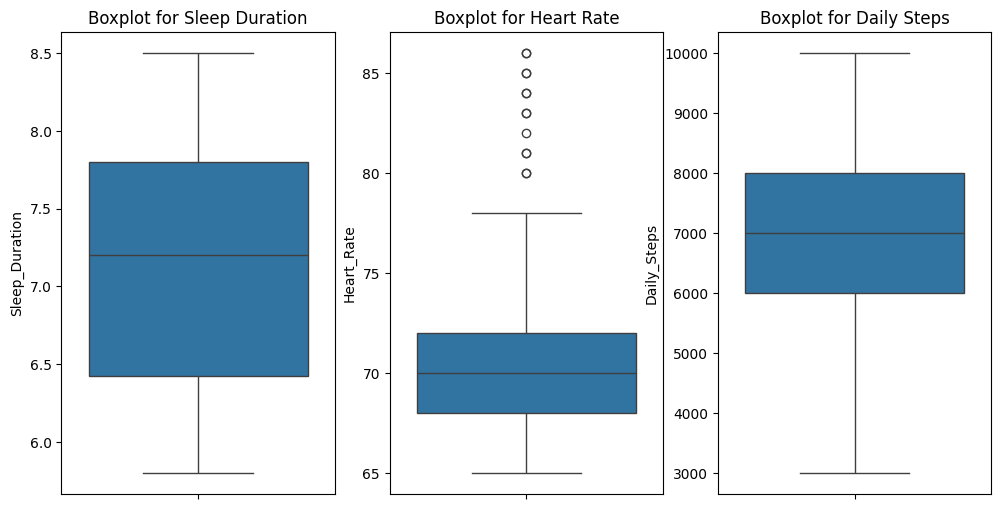

In [129]:
# Постройте boxplot для столбцов Sleep_Duration, Heart_Rate, Daily_Steps
import seaborn as sns
plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
sns.boxplot(y=df_sleep['Sleep_Duration'])
plt.title('Boxplot for Sleep Duration')

plt.subplot(1, 3, 2)
sns.boxplot(y=df_sleep['Heart_Rate'])
plt.title('Boxplot for Heart Rate')

plt.subplot(1, 3, 3)
sns.boxplot(y=df_sleep['Daily_Steps'])
plt.title('Boxplot for Daily Steps')

plt.show()



In [123]:
# Для Heart_Rate используйте z-score для выявления выбросов
df_sleep['Heart_Rate_zscore'] = scipy.stats.zscore(df_sleep['Heart_Rate'])
outliers = df_sleep[df_sleep['Heart_Rate_zscore'].abs() > 3]
display(outliers)

,Person_ID,Gender,Age,Occupation,Sleep_Duration,Quality_of_Sleep,Physical_Activity_Level,Stress_Level,BMI_Category,Blood_Pressure,Heart_Rate,Daily_Steps,Sleep_Disorder,Heart_Rate_zscore
3,4,Male,28,sales representative,5.9,4,30.0,8,Obese,140,85.0,3000.0,Sleep Apnea,3.731290
5,6,Male,28,software engineer,5.9,4,30.0,8,Obese,140,85.0,3000.0,Insomnia,3.731290
96,94,Male,35,lawyer,7.4,7,60.0,5,Obese,135,84.0,3300.0,Sleep Apnea,3.482138
148,146,Female,38,lawyer,7.4,7,60.0,5,Obese,135,84.0,3300.0,Sleep Apnea,3.482138
267,265,Male,48,doctor,7.3,7,65.0,5,Obese,142,83.0,3500.0,Insomnia,3.232986
269,267,Male,48,doctor,7.3,7,65.0,5,Obese,142,83.0,3500.0,Insomnia,3.232986
279,277,Male,49,doctor,8.1,9,85.0,3,Obese,139,86.0,3700.0,Sleep Apnea,3.980443
280,278,Male,49,doctor,8.1,9,85.0,3,Obese,139,86.0,3700.0,Sleep Apnea,3.980443


<b> 8. Кодирование категориальных признаков </b>

In [132]:
# спользуйте кодирование лейблов для столбцов Gender и BMI_Category
pd.factorize(df_sleep['Gender'])
pd.factorize(df_sleep['BMI_Category'])

(array([0, 1, 1, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 1, 3, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 3, 3, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        3, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 3, 1, 1, 1,
        1, 1, 1, 1, 1, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 3, 3,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 0, 3, 3, 3, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 3, 3, 1, 1, 1, 3, 0, 0, 1, 1, 1, 1, 1, 1, 1,
        1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 1, 1, 3, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        2, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

In [133]:
df_sleep['Gender_encoded'] = pd.factorize(df_sleep['Gender'])[0]
df_sleep['BMI_Category_encoded'] = pd.factorize(df_sleep['BMI_Category'])[0]
df_sleep

,Person_ID,Gender,Age,Occupation,Sleep_Duration,Quality_of_Sleep,Physical_Activity_Level,Stress_Level,BMI_Category,Blood_Pressure,Heart_Rate,Daily_Steps,Sleep_Disorder,Heart_Rate_zscore,Gender_encoded,BMI_Category_encoded
0,1,1,27,software engineer,6.1,6,42.0,6,3,126,77.0,4200.0,Without Disorder,1.738071,0,0
1,2,1,28,doctor,6.2,6,60.0,8,0,125,75.0,10000.0,Without Disorder,1.239766,0,1
2,3,1,28,doctor,6.2,6,60.0,8,0,125,75.0,10000.0,Without Disorder,1.239766,0,1
3,4,1,28,sales representative,5.9,4,30.0,8,2,140,85.0,3000.0,Sleep Apnea,3.731290,0,2
4,5,1,28,sales representative,5.9,4,30.0,8,2,140,68.0,3000.0,Sleep Apnea,-0.504300,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
372,370,0,59,nurse,8.1,9,75.0,3,3,140,68.0,7000.0,Sleep Apnea,-0.504300,1,0
373,371,0,59,nurse,8.0,9,75.0,3,3,140,68.0,7000.0,Sleep Apnea,-0.504300,1,0
374,372,0,59,nurse,8.1,9,75.0,3,3,140,68.0,7000.0,Sleep Apnea,-0.504300,1,0
375,373,0,59,nurse,8.1,9,75.0,3,3,140,68.0,7000.0,Sleep Apnea,-0.504300,1,0
